In [15]:
from google.colab import files
files.upload()

Saving DataSetRLM.csv to DataSetRLM.csv


{'DataSetRLM.csv': b'prec,flex,resl,team,pmat,rely,data,cplx,ruse,docu,time,stor,pvol,acap,pcap,pcon,apex,plex,ltex,tool,site,sced,kloc,effort,Team Size ,Lack of Team Trust,Competence Level,Client Involvement ,Geographic distribution ,Knowledge Management ,Project Effort,Design and technology newness,Communication Infrastructure ,Work Dispersion,Response Delay,Task Allocation,Travel Cost,Time zone difference,Language/Cultural difference,Project Management Effort,Contract Design ,Rework,Requirements Legibility,Sharing of Resources,Development Productivity,Reuse,Process Compliance ,Process Maturity,Process Model,Work Pressure\r\n2.48,2.03,2.83,1.1,3.12,1.1,0.9,1.17,1,1,1,1,0.78,1,1,1,1,1,0.91,1,1,1.14,25.9,117.6,1.15,1.15,0.85,0.85,1.15,0.85,1.15,1.15,0.85,0.85,1.15,0.85,1.15,1.15,1.15,1.15,0.85,1.15,0.85,0.85,0.85,0.85,0.85,0.85,0.85,1.15\r\n2.48,2.03,2.83,1.1,3.12,1.1,0.9,1.17,1,1,1,1,0.78,1,1,1,1,1,0.91,1,1,1.14,24.6,117.6,1.15,1.15,0.85,0.85,1.15,0.85,1.15,1.15,0.85,0.85,1.15,0.85,1.

In [14]:
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
df = pd.read_csv("DataSetRLM.csv")
df.columns = df.columns.str.strip()

mapa = {"effort": "Horas_Dev", "kloc": "Linhas_Codigo_KLOC",
        "cplx": "Complexidade_Ciclomatica_Media", "apex": "Experiencia_Equipe_Anos"}
dados = df[list(mapa)].rename(columns=mapa)

print(dados.describe(percentiles=[.25, .5, .75, .9]).round(2))

       Horas_Dev  Linhas_Codigo_KLOC  Complexidade_Ciclomatica_Media  \
count      93.00               93.00                           93.00   
mean      624.41               94.02                            1.20   
std      1135.93              133.60                            0.17   
min         8.40                0.90                            0.87   
25%        70.00               15.40                            1.17   
50%       252.00               47.50                            1.17   
75%       600.00              111.00                            1.17   
90%      1590.32              238.60                            1.34   
max      8211.00              980.00                            1.74   

       Experiencia_Equipe_Anos  
count                    93.00  
mean                      0.92  
std                       0.07  
min                       0.81  
25%                       0.88  
50%                       0.88  
75%                       1.00  
90%            

                                Horas_Dev  Linhas_Codigo_KLOC  \
Horas_Dev                            1.00                0.59   
Linhas_Codigo_KLOC                   0.59                1.00   
Complexidade_Ciclomatica_Media      -0.02               -0.23   
Experiencia_Equipe_Anos             -0.13               -0.23   

                                Complexidade_Ciclomatica_Media  \
Horas_Dev                                                -0.02   
Linhas_Codigo_KLOC                                       -0.23   
Complexidade_Ciclomatica_Media                            1.00   
Experiencia_Equipe_Anos                                   0.05   

                                Experiencia_Equipe_Anos  
Horas_Dev                                         -0.13  
Linhas_Codigo_KLOC                                -0.23  
Complexidade_Ciclomatica_Media                     0.05  
Experiencia_Equipe_Anos                            1.00  


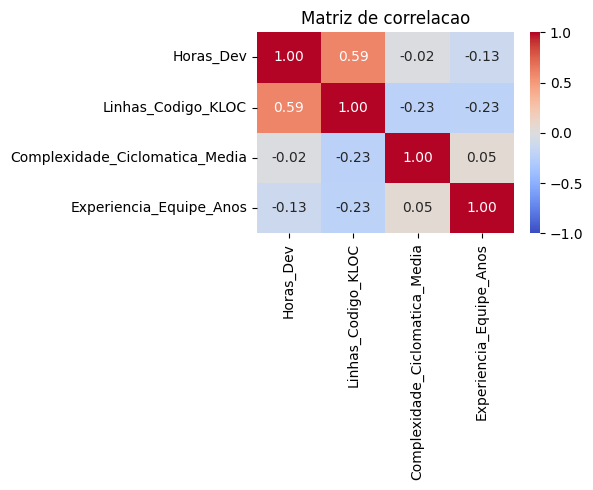

In [18]:
corr = dados.corr()
print(corr.round(2))
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlacao")
plt.tight_layout()
plt.show()

In [19]:
X = dados.drop(columns="Horas_Dev")
y = dados["Horas_Dev"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

ols = sm.OLS(y_tr, sm.add_constant(X_tr)).fit()
print(ols.summary())
print("R2:", round(ols.rsquared, 3), "| R2 ajustado:", round(ols.rsquared_adj, 3))

                            OLS Regression Results                            
Dep. Variable:              Horas_Dev   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.333
Method:                 Least Squares   F-statistic:                     13.15
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           6.66e-07
Time:                        12:48:32   Log-Likelihood:                -615.55
No. Observations:                  74   AIC:                             1239.
Df Residuals:                      70   BIC:                             1248.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [20]:
lr = LinearRegression().fit(X_tr, y_tr)
pred = lr.predict(X_te)
print("R2 teste:", round(r2_score(y_te, pred), 3))
print("MAE:", round(mean_absolute_error(y_te, pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_te, pred)), 2))

R2 teste: -0.099
MAE: 259.07
RMSE: 371.92
